> # Libraries

In [ ]:
# !pip install Augmentor
# import Augmentor

import os
import shutil
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow import keras
from keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, AveragePooling2D, Concatenate, Flatten, Dense
from tensorflow.keras import Model
from keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


> # Handle Warnings

> # Define Paths

In [ ]:
data_path = "/content/drive/MyDrive/Đồ Án DIP/archive/Student-engagement-processed"
target_path = '/content/Student-engagement-Processed'
train_dir = os.path.join(target_path, 'train')
test_dir = os.path.join(target_path, 'test')
valid_dir = os.path.join(target_path, 'validation')

os.makedirs(target_path,exist_ok=True)
os.makedirs(train_dir,exist_ok=True)
os.makedirs(test_dir,exist_ok=True)
os.makedirs(valid_dir,exist_ok=True)

> # Data Preprocessing and Split data into train and test with ratio 20%

In [ ]:
img_size = (256, 256)
for path_ in os.listdir(data_path):
    main_class_dir = os.path.join(data_path, path_)
    for subclass_name in os.listdir(main_class_dir):
        subclass_dir = os.path.join(main_class_dir, subclass_name)

        img_count = len(os.listdir(subclass_dir))                              # Get images coount in each class
        test_img_count = int(0.2*img_count)                                    # Number of test images
        train_img_count = img_count - test_img_count                           # Number of train images


        target_train_class_dir = os.path.join(train_dir, subclass_name)
        target_test_class_dir = os.path.join(test_dir, subclass_name)
        target_valid_class_dir = os.path.join(valid_dir, subclass_name)

        os.makedirs(target_train_class_dir,exist_ok=True)                      # Create train directory path
        os.makedirs(target_test_class_dir,exist_ok=True)                       # Create test directory path
        os.makedirs(target_valid_class_dir,exist_ok=True)                       # Create validation directory path

        for file_name in os.listdir(subclass_dir):
            img = cv2.imread(os.path.join(subclass_dir, file_name))
            img = cv2.resize(img, img_size)                                    # Resize image to 224 x 224
            img = img / 255.0                                                  # Normalize pixel values to [0, 1]

            if len(os.listdir(target_test_class_dir)) != test_img_count:
                cv2.imwrite(os.path.join(target_test_class_dir, file_name), img)
            else:
                cv2.imwrite(os.path.join(target_train_class_dir, file_name), img)

> # Apply Data Augmentation in Train Data

In [ ]:
# new_train_path = '/kaggle/working/Student-engagement-Dataset/Train'
# os.makedirs(new_train_path,exist_ok=True)

# for class_folder in os.listdir(train_dir):
#     class_dir = os.path.join(train_dir, class_folder)
#     new_class_dir = os.path.join(new_train_path, class_folder)
#     os.makedirs(new_class_dir,exist_ok=True)
#     p = Augmentor.Pipeline(class_dir,new_class_dir)
#     p.rotate(probability=1, max_left_rotation=5, max_right_rotation=5)
#     p.flip_left_right(probability=0.5)
#     p.zoom_random(probability=0.5, percentage_area=0.8)
#     p.flip_top_bottom(probability=0.5)
#     p.flip_random(probability=0.5)
#     p.sample(500)

# shutil.rmtree(train_dir)
# train_dir = new_train_path

> # Split Train into train and validation

In [ ]:
for class_folder in os.listdir(train_dir):
    train_class_dir = os.path.join(train_dir, class_folder)
    valid_class_dir = os.path.join(valid_dir, class_folder)

    train_ = os.path.join(target_path,'Train')
    os.makedirs(train_,exist_ok=True)
    new_class_dir = os.path.join(train_,class_folder)
    os.makedirs(new_class_dir,exist_ok=True)

    img_count =  len(os.listdir(train_class_dir))                           # Get images coount in each class
    valid_img_count = int(0.2*img_count)                                    # Number of validation images
    train_img_count = img_count - valid_img_count                           # Number of train images

    for file_name in os.listdir(train_class_dir):
        img = cv2.imread(os.path.join(train_class_dir, file_name))
        if len(os.listdir(valid_class_dir)) != valid_img_count:
            cv2.imwrite(os.path.join(valid_class_dir, file_name), img)
        else:
            cv2.imwrite(os.path.join(new_class_dir, file_name), img)

shutil.rmtree(train_dir)
train_dir = train_

In [ ]:
batch_size = 32
img_size = (256, 256,3)

train_datagen = ImageDataGenerator()
val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()


train_generator = train_datagen.flow_from_directory(
        train_dir,
        batch_size=batch_size,
        class_mode = 'categorical',
        shuffle=True)


val_generator = val_datagen.flow_from_directory(
        valid_dir,
        batch_size=batch_size,
        class_mode = 'categorical',
        shuffle=True)

test_generator = test_datagen.flow_from_directory(
        test_dir,
        batch_size=batch_size,
        class_mode = 'categorical',
        shuffle=True)

print(train_generator.class_indices)

Found 1362 images belonging to 6 classes.
Found 337 images belonging to 6 classes.
Found 421 images belonging to 6 classes.
{'Looking Away': 0, 'bored': 1, 'confused': 2, 'drowsy': 3, 'engaged': 4, 'frustrated': 5}


> # Build Resnet50 Model

In [ ]:
# def inception_module(x, filters):
#     # 1x1 Convolution
#     conv1x1 = Conv2D(filters=filters[0], kernel_size=(1, 1), padding='same', activation='relu')(x)

#     # 1x1 Convolution followed by 3x3 Convolution
#     conv1x1_3x3 = Conv2D(filters=filters[1], kernel_size=(1, 1), padding='same', activation='relu')(x)
#     conv1x1_3x3 = Conv2D(filters=filters[2], kernel_size=(3, 3), padding='same', activation='relu')(conv1x1_3x3)

#     # 1x1 Convolution followed by 5x5 Convolution
#     conv1x1_5x5 = Conv2D(filters=filters[3], kernel_size=(1, 1), padding='same', activation='relu')(x)
#     conv1x1_5x5 = Conv2D(filters=filters[4], kernel_size=(5, 5), padding='same', activation='relu')(conv1x1_5x5)

#     # 3x3 MaxPooling followed by 1x1 Convolution
#     maxpool = MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding='same')(x)
#     conv3x3_1x1 = Conv2D(filters=filters[5], kernel_size=(1, 1), padding='same', activation='relu')(maxpool)

#     # Concatenate the output of all branches
#     inception_output = Concatenate(axis=-1)([conv1x1, conv1x1_3x3, conv1x1_5x5, conv3x3_1x1])

#     return inception_output

# # Build the InceptionV2 model
# input_tensor = Input(img_size)
# x = Conv2D(64, (7, 7), strides=(2, 2), padding='same', activation='relu')(input_tensor)
# x = MaxPooling2D(pool_size=(3, 3), strides=(2, 2))(x)
# x = Conv2D(64, (1, 1), padding='same', activation='relu')(x)
# x = Conv2D(192, (3, 3), padding='same', activation='relu')(x)
# x = MaxPooling2D(pool_size=(3, 3), strides=(2, 2))(x)

# # Inception Modules
# x = inception_module(x, filters=[64, 128, 128, 32, 32, 32])
# x = inception_module(x, filters=[128, 192, 96, 96, 64, 64])
# x = MaxPooling2D(pool_size=(3, 3), strides=(2, 2))(x)

# x = GlobalAveragePooling2D()(x)

# output_tensor = Dense(6, activation='softmax')(x)

# model = Model(inputs=input_tensor, outputs=output_tensor)
# model.summary()



model = keras.models.Sequential([
    keras.layers.Conv2D(32, (1,1), activation='relu', input_shape=img_size),
    keras.layers.MaxPooling2D(3,3),
    keras.layers.Conv2D(64, (1,1), activation='relu'),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(3,3),
    keras.layers.Conv2D(128, (1,1), activation='relu'),
     keras.layers.Conv2D(128, (5,5), activation='relu'),
    keras.layers.MaxPooling2D(3,3),
    keras.layers.Conv2D(256, (1,1), activation='relu'),
     keras.layers.Conv2D(256, (5,5), activation='relu'),
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(6, activation='softmax')
])
model.summary()

model.compile(optimizer=Adam() ,loss="categorical_crossentropy", metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 85, 85, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 85, 85, 64)     │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 83, 83, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 27, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 27, 27, 128)    │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 23, 23, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 256)      │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 3, 3, 256)      │     1,638,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,312,134 (12.63 MB)

 Trainable params: 3,312,134 (12.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "Student Engagement Model.h5",
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='auto',
    save_freq='epoch'
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=9,
    verbose=1,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[checkpoint, early_stopping]
)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5239 - loss: 1.1311
Epoch 1: val_accuracy improved from -inf to 0.94065, saving model to Student Engagement Model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 171s 4s/step - accuracy: 0.5285 - loss: 1.1204 - val_accuracy: 0.9407 - val_loss: 0.1306
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9451 - loss: 0.1275
Epoch 2: val_accuracy improved from 0.94065 to 0.94362, saving model to Student Engagement Model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 193s 4s/step - accuracy: 0.9451 - loss: 0.1274 - val_accuracy: 0.9436 - val_loss: 0.1080
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9561 - loss: 0.0903
Epoch 3: val_accuracy improved from 0.94362 to 0.95549, saving model to Student Engagement Model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 168s 4s/step - accuracy: 0.9561 - loss: 0.0904 - val_accuracy: 0.9555 - val_loss: 0.0940
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9590 - loss: 0.0763
Epoch 4: val_accuracy did not improve from 0.95549
43/43 ━━━━━━━━━━━━━━━━━━━━ 167s 4s/step - accuracy: 0.9590 - loss: 0.0762 - val_accuracy: 0.9525 - val_loss: 0.0948
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9720 - loss: 0.0599
Epoch 5: val_accuracy did not improve from 0.95549
43/43 ━━━━━━━━━━━━━━━━━━━━ 157s 4s/step - accuracy: 0.9720 - loss: 0.0599 - val_accuracy: 0.9496 - val_loss: 0.1031
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9594 - loss: 0.0768
Epoch 6: val_accuracy improved from 0.95549 to 0.97329, saving model to Student Engagement Model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 159s 4s/step - accuracy: 0.9597 - loss: 0.0764 - val_accuracy: 0.9733 - val_loss: 0.0568
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9830 - loss: 0.0559
Epoch 7: val_accuracy did not improve from 0.97329
43/43 ━━━━━━━━━━━━━━━━━━━━ 161s 4s/step - accuracy: 0.9830 - loss: 0.0561 - val_accuracy: 0.9674 - val_loss: 0.0733
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9800 - loss: 0.0452
Epoch 8: val_accuracy did not improve from 0.97329
43/43 ━━━━━━━━━━━━━━━━━━━━ 167s 4s/step - accuracy: 0.9798 - loss: 0.0454 - val_accuracy: 0.9733 - val_loss: 0.0687
Epoch 9/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9777 - loss: 0.0449
Epoch 9: val_accuracy improved from 0.97329 to 0.97626, saving model to Student Engagement Model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 159s 4s/step - accuracy: 0.9778 - loss: 0.0450 - val_accuracy: 0.9763 - val_loss: 0.0600
Epoch 10/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9772 - loss: 0.0454
Epoch 10: val_accuracy did not improve from 0.97626
43/43 ━━━━━━━━━━━━━━━━━━━━ 160s 4s/step - accuracy: 0.9774 - loss: 0.0452 - val_accuracy: 0.9525 - val_loss: 0.0997
Epoch 11/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9830 - loss: 0.0413
Epoch 11: val_accuracy did not improve from 0.97626
43/43 ━━━━━━━━━━━━━━━━━━━━ 159s 4s/step - accuracy: 0.9830 - loss: 0.0413 - val_accuracy: 0.9703 - val_loss: 0.0650
Epoch 12/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9874 - loss: 0.0275
Epoch 12: val_accuracy did not improve from 0.97626
43/43 ━━━━━━━━━━━━━━━━━━━━ 168s 4s/step - accuracy: 0.9874 - loss: 0.0276 - val_accuracy: 0.9614 - val_loss: 0.0813
Epoch 13/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9857 - loss: 0.0427
Epoch 13: val_accuracy did not improve from 

43/43 ━━━━━━━━━━━━━━━━━━━━ 159s 4s/step - accuracy: 0.9835 - loss: 0.0484 - val_accuracy: 0.9792 - val_loss: 0.0551
Epoch 16/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9898 - loss: 0.0253
Epoch 16: val_accuracy did not improve from 0.97923
43/43 ━━━━━━━━━━━━━━━━━━━━ 203s 4s/step - accuracy: 0.9897 - loss: 0.0253 - val_accuracy: 0.9763 - val_loss: 0.0599
Epoch 17/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9862 - loss: 0.0217
Epoch 17: val_accuracy did not improve from 0.97923
43/43 ━━━━━━━━━━━━━━━━━━━━ 157s 4s/step - accuracy: 0.9862 - loss: 0.0217 - val_accuracy: 0.9733 - val_loss: 0.0766
Epoch 18/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9869 - loss: 0.0256
Epoch 18: val_accuracy did not improve from 0.97923
43/43 ━━━━━━━━━━━━━━━━━━━━ 155s 4s/step - accuracy: 0.9869 - loss: 0.0256 - val_accuracy: 0.9763 - val_loss: 0.0730
Epoch 19/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9924 - loss: 0.0134
Epoch 19: val_accuracy did not improve from 

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

# Print the test loss and accuracy
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 938ms/step - accuracy: 0.9434 - loss: 0.1687
Test Loss: 0.2012
Test Accuracy: 0.9335


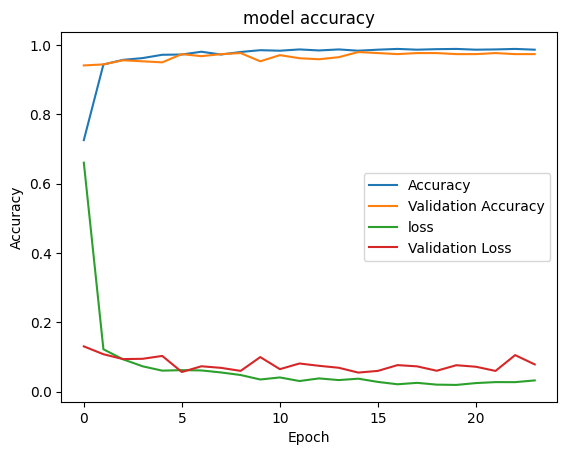

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("model accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy","Validation Accuracy","loss","Validation Loss"])
plt.show()